## import Libraries

In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))

In [2]:
from src.Data_preprocessing import preprocess
from src.Feature_Engineering import feature_Engineering
df=preprocess() 
df=feature_Engineering(df)

c:\Users\za813\anaconda3\envs\medical_cost\python.exe
2.2.3


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Bmi Categories

### I created bmi_category because BMI has well-defined medical categories. These categories may capture health risk better than the raw BMI value, allowing the model to learn different behaviors for Normal, Overweight, and Obese patients. I then compared the engineered feature with the original BMI feature using cross-validation to determine whether it improved performance

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_category
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,Young Adult
1,18,male,33.770,1,no,southeast,1725.55230,Obesity I,Young Adult
2,28,male,33.000,3,no,southeast,4449.46200,Obesity I,Young Adult
3,33,male,22.705,0,no,northwest,21984.47061,Normal,Middle Aged
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,Middle Aged


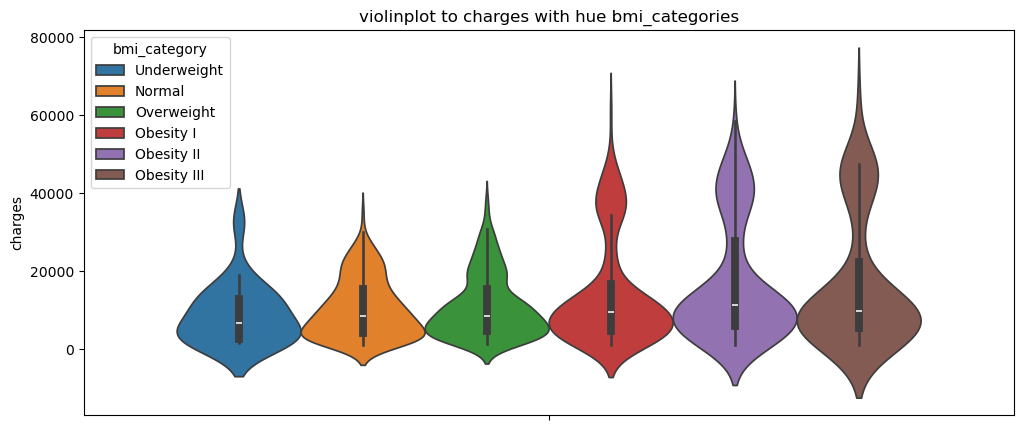

In [5]:
plt.figure(figsize=(12,5))
sns.violinplot(
    data=df,
    y="charges",
    hue="bmi_category"
)
plt.title("violinplot to charges with hue bmi_categories")
plt.savefig("../Figures/violinplot to charges with hue bmi_categories.png")
plt.show()

## bmi and Smoker

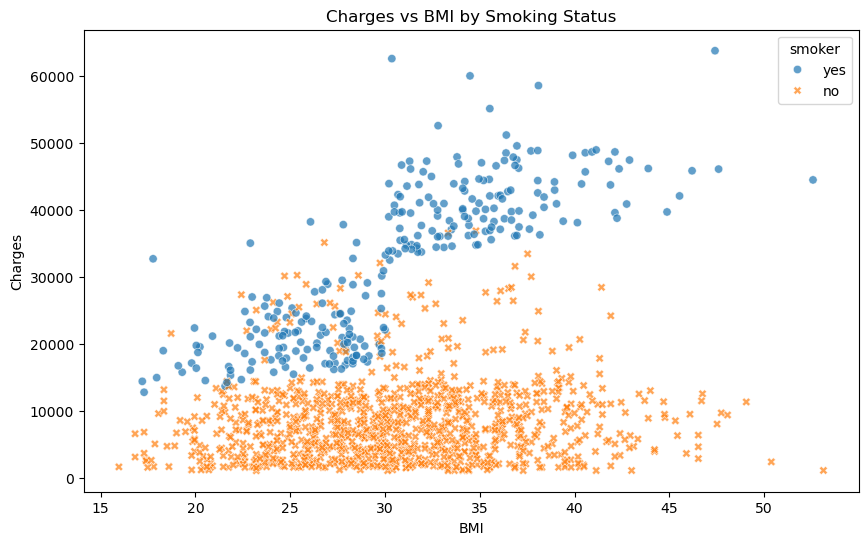

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker",
    style="smoker",
    alpha=0.7
)

plt.title("Charges vs BMI by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

- **Costs rise significantly for smokers who have a high BMI. Conversely, a smoker might still incur low costs if their BMI is low.**

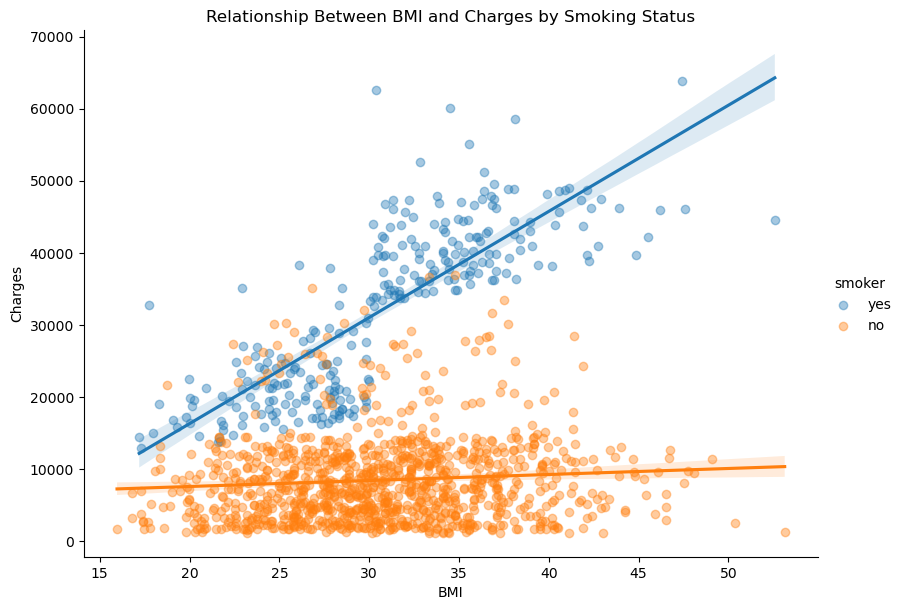

In [7]:
sns.lmplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker",
    height=6,
    aspect=1.4,
    scatter_kws={"alpha": 0.4}
)

plt.title("Relationship Between BMI and Charges by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

- **Smoking status has a strong effect on medical charges, and this effect becomes more pronounced as BMI increases. Smokers generally have much higher charges than non-smokers, and the positive relationship between BMI and charges is considerably stronger among smokers.**

- **BMI has a stronger positive relationship with medical charges among smokers than non-smokers, suggesting an interaction between BMI and smoking status.**

- df["bmi_smoker"] = (
    df["bmi"] * (df["smoker"] == "yes").astype(int)
)

- **Note**

- **------------------------------------------------------------------------------------------------------------------------------**

- **Although the visualization suggested an interaction between smoking status and BMI, the binary interaction feature did not improve the Random Forest model, indicating that the original continuous features already captured this relationship effectively.**

- **------------------------------------------------------------------------------------------------------------------------------**